1) Расчёт Pearson и Spearman + scatter plot с линией регрессии

Pearson r = 0.995, p = 3.693e-09
Spearman rho = 0.988, p = 9.307e-08


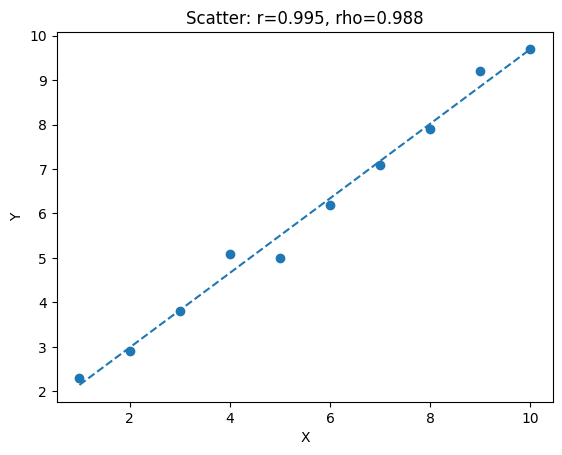

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, linregress

# Пример данных
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([2.3,2.9,3.8,5.1,5.0,6.2,7.1,7.9,9.2,9.7])

# Коэффициенты
r, pval_r = pearsonr(x, y)
rho, pval_rho = spearmanr(x, y)
print(f"Pearson r = {r:.3f}, p = {pval_r:.3e}")
print(f"Spearman rho = {rho:.3f}, p = {pval_rho:.3e}")

# График + линия наилучшей линейной аппроксимации
slope, intercept, r_val, p_val, stderr = linregress(x, y)
plt.scatter(x, y)
plt.plot(x, intercept + slope*x, linestyle='--')   # линия регрессии
plt.xlabel("X")
plt.ylabel("Y")
plt.title(f"Scatter: r={r:.3f}, rho={rho:.3f}")
plt.show()

2) Тест значимости и доверительный интервал для  (Fisher z)

In [2]:
import numpy as np
from scipy.stats import norm
def fisher_ci(r, n, alpha=0.05):
    z = np.arctanh(r)
    se = 1/np.sqrt(n-3)
    z_crit = norm.ppf(1-alpha/2)
    lo = np.tanh(z - z_crit*se)
    hi = np.tanh(z + z_crit*se)
    return lo, hi

lo, hi = fisher_ci(r, len(x))
print(f"95% CI for r (Fisher): [{lo:.3f}, {hi:.3f}]")

95% CI for r (Fisher): [0.976, 0.999]


3) Пример влияния выброса

In [3]:
import numpy as np
from scipy.stats import pearsonr

x2 = x.copy()
y2 = y.copy()
# добавим один выброс в конец
x2 = np.append(x2, 100)
y2 = np.append(y2, -50)

print("Без выброса:", pearsonr(x, y))
print("С выбросом:", pearsonr(x2, y2))

Без выброса: PearsonRResult(statistic=np.float64(0.9946009511782545), pvalue=np.float64(3.693435805968025e-09))
С выбросом: PearsonRResult(statistic=np.float64(-0.9706591890059193), pvalue=np.float64(7.123496752239846e-07))


In [8]:
x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
y = [2.3, 2.9, 3.8, 5.1, 5.0, 6.2, 7.1, 7.9, 9.2, 9.7]
r, pval_r = pearsonr(x, y)
round(r,3)

lo, hi = fisher_ci(r, len(x))
print(f"95% CI for r (Fisher): [{lo:.3f}, {hi:.3f}]")

95% CI for r (Fisher): [0.976, 0.999]


1) Быстрый расчёт r, t, p-value и Fisher CI

In [9]:
import numpy as np
from scipy import stats

x = np.array([3.63,3.02,3.82,3.42,3.59,2.87,3.03,3.46,3.36,3.30])
y = np.array([53.1,49.7,48.4,54.2,54.9,43.7,47.2,45.2,54.4,50.4])
n = len(x)

# Pearson r и p-value (scipy)
r, p_two = stats.pearsonr(x, y)
print(f"Pearson r = {r:.3f}, two-sided p = {p_two:.3f}")

# t-статистика (вручную, проверка)
t_stat = r / np.sqrt((1 - r**2) / (n - 2))
print(f"t = {t_stat:.3f}, df = {n-2}")

# Fisher z CI
z = np.arctanh(r)
se_z = 1/np.sqrt(n-3)
z_crit = stats.norm.ppf(0.975)
lo = np.tanh(z - z_crit * se_z)
hi = np.tanh(z + z_crit * se_z)
print(f"95% Fisher CI for rho: [{lo:.3f}, {hi:.3f}]")

Pearson r = 0.470, two-sided p = 0.170
t = 1.507, df = 8
95% Fisher CI for rho: [-0.227, 0.849]


2) Визуализация и проверка выбросов

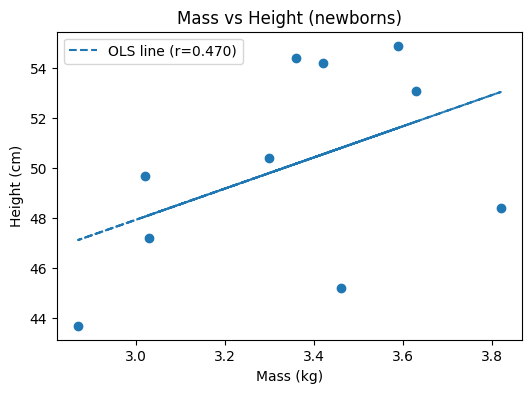

In [10]:
import matplotlib.pyplot as plt
slope, intercept, r_val, p_val, stderr = stats.linregress(x, y)

plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, intercept + slope*x, linestyle='--', label=f"OLS line (r={r:.3f})")
plt.xlabel("Mass (kg)")
plt.ylabel("Height (cm)")
plt.title("Mass vs Height (newborns)")
plt.legend()
plt.show()

a) Быстрый расчёт Spearman (scipy)

In [11]:
import numpy as np
from scipy import stats

x = np.array([106,100,86,101,99,103,97,112,113,110])
y = np.array([7,27,2,50,28,29,20,6,12,17])

rho, pval = stats.spearmanr(x, y)
print(f"Spearman rho = {rho:.3f}, p-value = {pval:.3f}")

Spearman rho = -0.176, p-value = 0.627


b) Ручной подсчёт через ранги и формулу

In [12]:
import numpy as np
from scipy.stats import rankdata

Rx = rankdata(x, method='average')   # ранги x (средние ранги при ties)
Ry = rankdata(y, method='average')
d = Rx - Ry
rs_manual = 1 - 6*np.sum(d**2)/(len(x)*(len(x)**2 - 1))
print("Rs manual:", round(rs_manual, 3))
# Также можно вычислить корреляцию Пирсона между рангами:
rs_via_pearson = np.corrcoef(Rx, Ry)[0,1]
print("Rs via pearson on ranks:", round(rs_via_pearson, 3))

Rs manual: -0.176
Rs via pearson on ranks: -0.176


c) Визуализация рангов и исходных данных

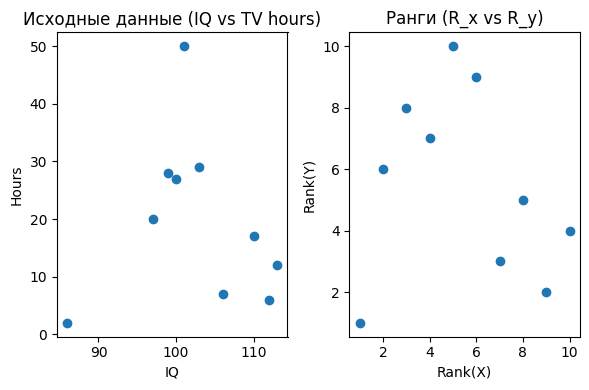

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.subplot(1,2,1)
plt.scatter(x, y)
plt.title("Исходные данные (IQ vs TV hours)")
plt.xlabel("IQ")
plt.ylabel("Hours")

plt.subplot(1,2,2)
plt.scatter(Rx, Ry)
plt.title("Ранги (R_x vs R_y)")
plt.xlabel("Rank(X)")
plt.ylabel("Rank(Y)")
plt.tight_layout()
plt.show()

d) Перестановочный тест (если хочется точного p-value для малых n)

In [14]:
def perm_test_spearman(x, y, B=10000, seed=1):
    rng = np.random.default_rng(seed)
    obs = stats.spearmanr(x, y).correlation
    count = 0
    for _ in range(B):
        y_perm = rng.permutation(y)
        if abs(stats.spearmanr(x, y_perm).correlation) >= abs(obs):
            count += 1
    return (count+1)/(B+1)

p_perm = perm_test_spearman(x, y, B=5000)
print("Permutation p-value (two-sided):", p_perm)

Permutation p-value (two-sided): 0.6336732653469306


$t = \frac{r_s}{\sqrt{(1 - r_s^2)/(n - 2)}}$

In [18]:
x.size

10

In [19]:
t=(rho)/(((1-rho**2)*(x.size-2))**0.5)
t

np.float64(-0.06312228114697932)

# Регрессия

A) statsmodels — полный вывод, CI, предсказания

In [27]:
import numpy as np
import statsmodels.api as sm

# примерные данные (масса -> рост), как в предыдущем примере
x = np.array([3.63,3.02,3.82,3.42,3.59,2.87,3.03,3.46,3.36,3.30])
y = np.array([53.1,49.7,48.4,54.2,54.9,43.7,47.2,45.2,54.4,50.4])

X = sm.add_constant(x)   # добавляем константу для intercept
model = sm.OLS(y, X).fit()
print(model.summary())

# предсказание и интервал для x0
x0 = np.array([1, 3.5])   # [const, x0]
pred = model.get_prediction(x0)

print(pred.summary_frame(alpha=0.05))  # mean, mean_ci_lower/upper, obs_ci_lower/upper

pred.predicted_mean


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.221
Model:                            OLS   Adj. R-squared:                  0.124
Method:                 Least Squares   F-statistic:                     2.270
Date:                Sun, 07 Dec 2025   Prob (F-statistic):              0.170
Time:                        13:52:44   Log-Likelihood:                -26.271
No. Observations:                  10   AIC:                             56.54
Df Residuals:                       8   BIC:                             57.15
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         29.2347     13.911      2.102      0.0

array([51.05516255])

B) NumPy / вручную

In [25]:
import numpy as np

n = len(x)
xbar, ybar = x.mean(), y.mean()
Sxx = np.sum((x - xbar)**2)
Sxy = np.sum((x - xbar)*(y - ybar))

b1 = Sxy / Sxx
b0 = ybar - b1*xbar
y_pred = b0 + b1*x
resid = y - y_pred
SSE = np.sum(resid**2)
s2 = SSE/(n-2)
se_b1 = np.sqrt(s2 / Sxx)

# 95% CI for slope
from scipy.stats import t
tcrit = t.ppf(0.975, n-2)
ci_b1 = (b1 - tcrit*se_b1, b1 + tcrit*se_b1)

b1
b0

np.float64(29.23470300659986)

# Парная линейная регрессия
A) Полная сводка через statsmodels

In [28]:
import numpy as np
import statsmodels.api as sm

x = np.array([3.63,3.02,3.82,3.42,3.59,2.87,3.03,3.46,3.36,3.30])
y = np.array([53.1,49.7,48.4,54.2,54.9,43.7,47.2,45.2,54.4,50.4])
X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
print(model.summary())

# Предсказание с интервалами для x0=3.5
x0 = np.array([1, 3.5])
pred = model.get_prediction(x0)
print(pred.summary_frame(alpha=0.05))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.221
Model:                            OLS   Adj. R-squared:                  0.124
Method:                 Least Squares   F-statistic:                     2.270
Date:                Sun, 07 Dec 2025   Prob (F-statistic):              0.170
Time:                        14:29:03   Log-Likelihood:                -26.271
No. Observations:                  10   AIC:                             56.54
Df Residuals:                       8   BIC:                             57.15
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         29.2347     13.911      2.102      0.0

B) Вручную на NumPy

In [29]:
import numpy as np
from scipy import stats

# данные x,y как выше
n = len(x)
xbar, ybar = x.mean(), y.mean()
Sxx = np.sum((x - xbar)**2)
Sxy = np.sum((x - xbar)*(y - ybar))

b1 = Sxy / Sxx
b0 = ybar - b1*xbar
yhat = b0 + b1*x
resid = y - yhat
SSE = np.sum(resid**2)
SST = np.sum((y - ybar)**2)
R2 = 1 - SSE/SST
s2 = SSE/(n-2)
se_b1 = np.sqrt(s2 / Sxx)
se_b0 = np.sqrt(s2*(1/n + xbar**2/Sxx))
t_b1 = b1 / se_b1
F = (R2/(1-R2))*(n-2)
# прогноз и предсказательный интервал для x0
x0 = 3.5
y0 = b0 + b1*x0
se_pred = np.sqrt(s2*(1 + 1/n + (x0 - xbar)**2 / Sxx))
tcrit = stats.t.ppf(0.975, n-2)
pi_lo, pi_hi = y0 - tcrit*se_pred, y0 + tcrit*se_pred

In [30]:
x = [1, 2, 4, 5, 7, 8]
y = [2.1, 2.9, 4.8, 5.3, 7.1, 8.2]

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     1148.
Date:                Sun, 07 Dec 2025   Prob (F-statistic):           4.53e-06
Time:                        14:31:36   Log-Likelihood:                 3.9002
No. Observations:                   6   AIC:                            -3.800
Df Residuals:                       4   BIC:                            -4.217
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2147      0.130      9.340      0.0

c:\Users\troyd\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [31]:
x = [2, 3, 4, 6, 7, 9]
y = [1.8, 2.5, 3.1, 4.7, 5.3, 6.8]

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
print(model.summary())

# Предсказание с интервалами для x0=3.5
x0 = np.array([1, 6.5])
pred = model.get_prediction(x0)
print(pred.summary_frame(alpha=0.05))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                     3856.
Date:                Sun, 07 Dec 2025   Prob (F-statistic):           4.03e-07
Time:                        14:32:47   Log-Likelihood:                 8.8211
No. Observations:                   6   AIC:                            -13.64
Df Residuals:                       4   BIC:                            -14.06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3301      0.066      5.017      0.0

c:\Users\troyd\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


# Множественная линейная регрессия


In [33]:
# X1, X2, Y (пример)
X1 = np.array([1,2,3,4,5,6,7,8,9,10])
X2 = np.array([2,1,4,3,5,7,6,8,9,10])
Y  = 3 + 2*X1 + 0.5*X2      # точная модель без шума

Statsmodels + вычисление VIF

In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# данные
df = pd.DataFrame({
    "X1": [1,2,3,4,5,6,7,8,9,10],
    "X2": [2,1,4,3,5,7,6,8,9,10],
})
df["Y"] = 3 + 2*df["X1"] + 0.5*df["X2"]

# OLS
X = sm.add_constant(df[["X1","X2"]])
y = df["Y"]
model = sm.OLS(y, X).fit()
print(model.summary())



                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 6.556e+29
Date:                Sun, 07 Dec 2025   Prob (F-statistic):          3.52e-103
Time:                        14:51:59   Log-Likelihood:                 303.17
No. Observations:                  10   AIC:                            -600.3
Df Residuals:                       7   BIC:                            -599.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0000   1.36e-14   2.21e+14      0.0

In [36]:
# стандартизация
X_std = (df[["X1","X2"]] - df[["X1","X2"]].mean()) / df[["X1","X2"]].std(ddof=0)
y_std = (df["Y"] - df["Y"].mean()) / df["Y"].std(ddof=0)
model_std = sm.OLS(y_std, sm.add_constant(X_std)).fit()
print("Standardized coefficients (approx):", model_std.params)

# VIF
vif_data = pd.DataFrame()
vif_data["feature"] = ["const","X1","X2"]
vif_data["VIF"] = [np.nan] + [
    variance_inflation_factor(X.values, i+1) for i in range(2)
]
print(vif_data)

Standardized coefficients (approx): const   -5.551115e-17
X1       8.046956e-01
X2       2.011739e-01
dtype: float64
  feature       VIF
0   const       NaN
1      X1  14.00463
2      X2  14.00463


# 1) Градиентный спуск для квадратичной функции

In [37]:
def gd_quadratic(eta=0.1, iters=10):
    w = 0.0
    hist = [w]
    for t in range(iters):
        grad = 2*(w - 3)               # производная f'(w) = 2(w-3)
        w = w - eta * grad
        hist.append(w)
    return np.array(hist)

print(gd_quadratic(eta=0.1, iters=3))  # ожидаем [0.0, 0.6, 1.08, 1.464]

[0.    0.6   1.08  1.464]


2) Градиентный спуск для простой линейной регрессии (MSE), батчевый вариант

In [38]:
# небольшие синтетические данные
x = np.array([1.0, 2.0, 3.0, 4.0])
y = np.array([3.0, 5.0, 7.0, 9.0])  # y ≈ 1 + 2*x

# инициализация
w = 0.0
b = 0.0
eta = 0.01
n_iter = 1000
n = len(x)

for epoch in range(n_iter):
    # предсказание
    y_hat = w * x + b
    # градиенты для MSE (с фактором 2/n)
    grad_w = (-2.0/n) * np.sum(x * (y - y_hat))
    grad_b = (-2.0/n) * np.sum(y - y_hat)
    # обновление
    w -= eta * grad_w
    b -= eta * grad_b

print("w, b:", round(w,3), round(b,3))  # ожидаем примерно w≈2, b≈1

w, b: 2.005 0.986
